<a href="https://colab.research.google.com/github/juanmorales2993/Ayudantias/blob/main/Ayudantia_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ayudantía 3: Introducción a Machine Learning y Árboles de Decisión**

**Curso:** Aplicaciones de Machine Learning en Economía

**Ayudantes:**
- Maykol Medrano -- mmedrano2@uc.cl
- Pablo Acevedo -- jbvillagra@uc.cl

Basado en el trabajo del equipo docente de semestres anteriores.

### **Contenidos**

1. **Regresión Lineal** — el modelo más clásico de la econometría, ahora visto desde la óptica de Machine Learning.
2. **Árboles de Decisión (Decision Trees)** — un modelo intuitivo que clasifica datos haciendo preguntas secuenciales.

**Conceptos importantes que veremos:**
- **Splitting de datasets** — separar datos en entrenamiento y prueba.
- **Regularización** — técnicas para evitar que el modelo "memorice" los datos (overfitting).
- **Cross Validation** — una forma robusta de evaluar qué tan bien generaliza nuestro modelo.

---

### **1. Regresión Lineal**

Imaginen que trabajan en una consultora y les piden estimar el **valor de las viviendas** en distritos de California. Tienen datos del censo: ingreso mediano, antigüedad, habitaciones... y el precio real. Si graficaran **ingreso vs. precio**, verían una tendencia clara: a mayor ingreso, mayor precio. Trazar una **línea** que resuma esa tendencia es, en esencia, un modelo de regresión lineal.

Lo interesante es que esa línea permite **predecir** valores nuevos. Si llega un distrito con ingreso de $45,000, podemos estimar el precio de sus viviendas — incluso si no estaba en nuestros datos.

**¿La diferencia con econometría?** En econometría importa *por qué* el ingreso afecta al precio (causalidad). En **ML**, la pregunta es: **¿qué tan bien predice mi modelo datos que nunca ha visto?**

#### **1.1 Dataset California Housing**

Usaremos el dataset **California Housing** de `sklearn`, del censo de EE.UU. de 1990. Contiene **20.640 distritos** con variables económicas y demográficas. El objetivo: predecir el **valor mediano de las viviendas** (la mediana del precio en el distrito, no el promedio).

In [ ]:
# Importamos las librerías que utilizaremos

from sklearn import datasets, linear_model
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split  # Particiona en datos de entrenamiento y prueba

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Librería que filtra warnings innecesarios
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Veamos la estructura cruda del dataset antes de transformarlo
housing = datasets.fetch_california_housing()
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
# Cargamos el dataset California Housing con Pandas
housing = datasets.fetch_california_housing()

# Transformamos datos a dataframe
df_housing = pd.DataFrame(data=housing['data'], columns=housing['feature_names'])

# Agregamos la variable objetivo (valor mediano de viviendas)
df_housing['MedHouseVal'] = housing['target']

df_housing  # Visualizamos la tabla

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


**Variables del dataset:**

| **Variable** | **Descripción** | **Unidad** |
|---|---|---|
| `MedInc` | **Ingreso mediano** del distrito | En decenas de miles de USD |
| `HouseAge` | **Antigüedad mediana** de las viviendas | Años |
| `AveRooms` | **Promedio de habitaciones** por hogar | Cantidad |
| `AveBedrms` | **Promedio de dormitorios** por hogar | Cantidad |
| `Population` | **Población** del distrito | Personas |
| `AveOccup` | **Promedio de ocupantes** por hogar | Personas |
| `Latitude` | **Latitud** del distrito | Grados |
| `Longitude` | **Longitud** del distrito | Grados |
| `MedHouseVal` | **Valor mediano de viviendas** (variable objetivo) | En cientos de miles de USD |

> **¿Mediana o promedio?** No es lo mismo. El dataset usa dos medidas distintas: las variables `Med` (como `MedInc`) usan la **mediana** — el valor del medio al ordenar todos los datos, más robusta a outliers. Las variables `Ave` (como `AveRooms`) usan el **promedio aritmético**. Por ejemplo, si en un distrito hay una mansión enorme, afecta al promedio pero no a la mediana.
>
> Un valor de `MedHouseVal = 2.5` significa que el valor mediano de las viviendas es 250,000 USD . Un valor de `MedInc = 3.87` significa que el ingreso mediano es 38,700 USD.

In [ ]:
# Estadísticas descriptivas transpuestas para mejor lectura
df_housing.describe().T.round(2).style.format("{:,.2f}")

,count,mean,std,min,25%,50%,75%,max
MedInc,"20,640.00",3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,"20,640.00",28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,"20,640.00",5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,"20,640.00",1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,"20,640.00","1,425.48","1,132.46",3.00,787.00,"1,166.00","1,725.00","35,682.00"
AveOccup,"20,640.00",3.07,10.39,0.69,2.43,2.82,3.28,"1,243.33"
Latitude,"20,640.00",35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,"20,640.00",-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,"20,640.00",2.07,1.15,0.15,1.20,1.80,2.65,5.00


#### **1.2 Visualización rápida de estadísticas**

Para explorar los datos rápidamente, podemos usar `seaborn`. Por ejemplo, un **heatmap de correlaciones** nos dice qué tanto se relacionan las variables entre sí (donde 1 es relación perfecta y -1 es inversa).

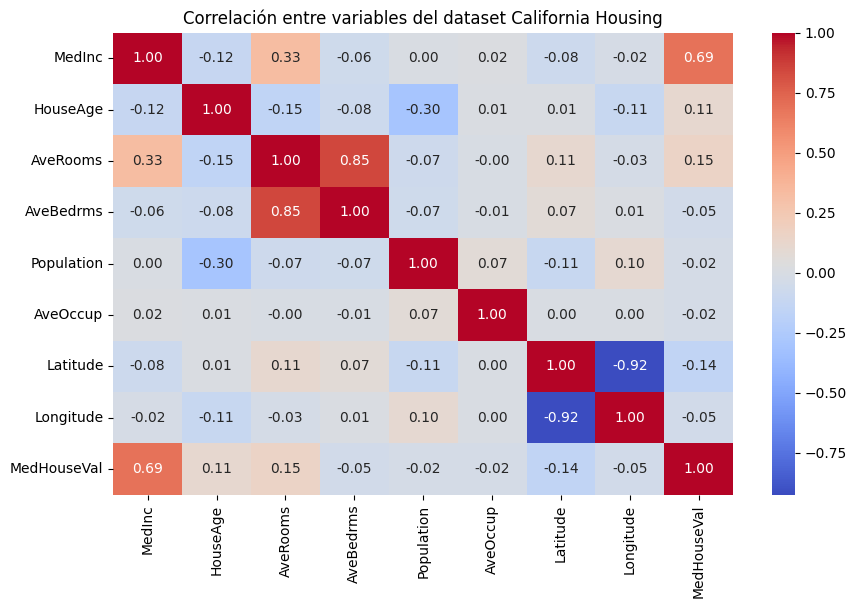

In [ ]:
# Quick Heatmap de correlaciones
plt.figure(figsize=(10, 6))
sns.heatmap(df_housing.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre variables del dataset California Housing')
plt.show()

#### **1.2 Modelos Lineales**

Volvamos a nuestra gráfica imaginaria de ingreso vs. precio de vivienda. Tenemos una nube de puntos y queremos trazar **la mejor línea posible**. ¿Qué significa "mejor"? Que la distancia entre lo que predice la línea y los valores reales sea **lo más pequeña posible**.

Eso es **Mínimos Cuadrados Ordinarios (OLS)**: buscamos los $\beta$ que minimicen la suma de errores al cuadrado:

$$\min_{\beta} \sum_{i=1}^{n} (y_i - X_i \beta)^2$$

> La intuición: tomamos todos los errores, los elevamos al cuadrado (penalizando más los errores grandes) y buscamos la línea que minimice esa suma.

| | **Econometría** | **Machine Learning** |
|---|---|---|
| **Foco** | Causalidad y significancia de $\beta$ | **Poder predictivo** con datos nuevos |
| **Evaluación** | Tests de hipótesis, p-values | Métricas ($R^2$, MSE) en datos de **prueba** |

##### **Train/Test Split: dividir los datos en 2**

En ML **no evaluamos con los mismos datos que entrenamos**. Queremos saber si el modelo aprendió patrones generales o simplemente "memorizó" (*overfitting*). Por eso dividimos el dataset en **2 partes aleatorias**:

```
  Dataset California Housing — 20,640 distritos (100%)
                        │
               train_test_split() (aleatorio 🎲)
                   ┌────┴────┐
                   ▼         ▼
       🟦 Training (~75%)   🟥 Test (~25%)
       El modelo APRENDE    Se evalúa con
       la relación          datos NUEVOS
                   │         │
              fit(X_train)  predict(X_test)
                   │         │
                   ▼         ▼
             Modelo    →   R²(y_test, y_pred)
             entrenado     ¿Qué tan bien predice?
```

> `train_test_split` selecciona filas **al azar**. Usamos `random_state` para que los resultados sean **reproducibles**.

In [ ]:
def regresion(X, Y):
    """Entrena una regresión lineal y muestra los resultados."""

    # Paso 1: Dividimos los datos — 75% entrenamiento, 25% prueba
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=15)

    # Paso 2: Creamos y entrenamos el modelo
    regr = linear_model.LinearRegression()
    regr.fit(X_train, y_train)

    # Paso 3: Generamos predicciones sobre datos que el modelo NUNCA vio
    y_pred = regr.predict(X_test)

    # Paso 4: Mostramos los resultados con etiquetas
    print("Coeficientes (efecto marginal sobre MedHouseVal, ceteris paribus):")
    for nombre, coef in zip(X.columns, regr.coef_):
        print(f"  {nombre:20s}: {round(coef, 4)}")
    print(f"\nIntercepto: {round(regr.intercept_, 4)}")
    print(f"R² (coeficiente de determinación): {round(r2_score(y_test, y_pred), 4)}")

    return X_test, y_test, y_pred

**¿Cómo saber si nuestro modelo es bueno?** Usamos el **coeficiente de determinación** $R^2$:

$$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

> No se asusten con la fórmula. La intuición es simple: $R^2$ compara los errores de nuestro modelo contra el "modelo más tonto posible" (predecir siempre el promedio). Si nuestro modelo no es mejor que eso, $R^2 = 0$.

- Si $R^2 = 1$ → el modelo **predice perfectamente** (nunca pasa en la realidad).
- Si $R^2 = 0$ → el modelo no es mejor que simplemente **predecir el promedio**.
- Si $R^2 < 0$ → el modelo es **peor** que predecir el promedio (algo anda muy mal).

##### **Primer modelo: una sola variable explicativa**

Empezamos con lo más simple: usar **solo el ingreso mediano** (`MedInc`) para predecir el **valor de la vivienda** (`MedHouseVal`). Es decir, ¿podemos estimar el precio de una casa en un distrito conociendo solo el ingreso de sus habitantes?

In [ ]:
# Variable explicativa: ingreso mediano del distrito
X = df_housing[['MedInc']]
# Variable objetivo: valor mediano de las viviendas
y = df_housing['MedHouseVal']

In [ ]:
# Visualizamos la variable objetivo (valor de viviendas en cientos de miles de USD)
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
# Utilizamos la función que creamos para entrenar la regresión
reg = regresion(X, y)

Coeficientes (efecto marginal sobre MedHouseVal, ceteris paribus):
  MedInc              : 0.4182

Intercepto: 0.4471
R² (coeficiente de determinación): 0.4695


##### **Segundo modelo: múltiples variables explicativas**

Ahora agregamos **antigüedad de la vivienda** (`HouseAge`) y **promedio de habitaciones** (`AveRooms`) como variables explicativas. La pregunta es: **¿mejora la predicción al incluir más información?** Observen cómo cambia el $R^2$.

In [ ]:
# Ahora usamos 3 variables explicativas
X = df_housing[['MedInc', 'HouseAge', 'AveRooms']]
y = df_housing['MedHouseVal']

reg = regresion(X, y)

Coeficientes (efecto marginal sobre MedHouseVal, ceteris paribus):
  MedInc              : 0.4416
  HouseAge            : 0.0173
  AveRooms            : -0.0231

Intercepto: -0.0132
R² (coeficiente de determinación): 0.5041


##### **¿Cómo interpretar los coeficientes?**

Cada coeficiente es el **efecto marginal** de esa variable sobre `MedHouseVal`, manteniendo las demás constantes (*ceteris paribus*). Por ejemplo:

- Si `MedInc` tiene coeficiente `0.45` → un aumento de **1 unidad en el ingreso mediano** (10,000 USD) se asocia con un aumento de **45,000 USD** en el valor mediano de las viviendas, dado el resto de variables.
- Si `HouseAge` tiene coeficiente `0.005` → casas 1 año más antiguas valen ~$500 más en mediana.

> Esto es idéntico a la interpretación de OLS en econometría. La diferencia es que en ML nos importa más el **R²** (qué tan bien predice el modelo en datos nuevos) que la significancia de cada coeficiente.

#### **1.3 Gráfico**

Visualicemos la regresión del **primer modelo** (solo `MedInc`). Los puntos negros son los datos reales de prueba y la línea azul es la predicción del modelo:

Coeficientes (efecto marginal sobre MedHouseVal, ceteris paribus):
  MedInc              : 0.4182

Intercepto: 0.4471
R² (coeficiente de determinación): 0.4695


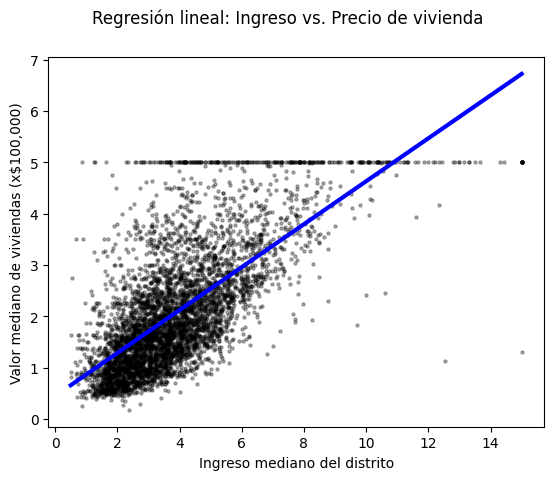

In [ ]:
# Gráfico con Pyplot
X = df_housing[['MedInc']]
y = df_housing['MedHouseVal']

X_test, y_test, y_pred = regresion(X, y)  # La función retorna estas 3 variables

plt.scatter(X_test, y_test, color="black", alpha=0.3, s=5)
plt.plot(X_test.sort_values('MedInc'), y_pred[X_test['MedInc'].argsort()], color="blue", linewidth=3)
plt.xlabel('Ingreso mediano del distrito')
plt.ylabel('Valor mediano de viviendas (x$100,000)')
plt.suptitle('Regresión lineal: Ingreso vs. Precio de vivienda')

plt.show()

---

### **2. Árboles de Decisión (Decision Trees)**

En la sección anterior usamos una regresión lineal para **predecir un número** (el precio de una vivienda). Ahora vamos a resolver un problema distinto: **clasificar personas** según su nivel de ingreso.

Ambos son problemas de **aprendizaje supervisado** — le mostramos al modelo ejemplos con respuesta conocida y aprende a generalizar. La diferencia:

| **Tipo** | **¿Qué predice?** | **Ejemplo en este notebook** |
|---|---|---|
| **Regresión** | Un **número** continuo | Precio de vivienda ($R^2$) |
| **Clasificación** | Una **categoría** | ¿Gana >$50K o ≤$50K? (accuracy) |

> **Recordatorio:** también existe el aprendizaje **no supervisado** (buscar patrones sin etiquetas, ej. clustering) y el **por refuerzo** (aprender por prueba y error). En este curso nos centramos en el supervisado.


#### **2.1 El problema: ¿quién gana más de $50K?**

Usaremos el dataset **Adult Income** (censo de EE.UU., 1994): **48,842 personas** con variables socioeconómicas. La pregunta es simple — dada la edad, educación y horas de trabajo de alguien, **¿podemos predecir si gana más o menos de $50,000 al año?**

| **Variable** | **Descripción** |
|---|---|
| `age` | Edad |
| `education-num` | Años de educación formal |
| `hours-per-week` | Horas de trabajo semanales |
| `capital-gain` | Ganancias de capital anuales (USD) |
| `capital-loss` | Pérdidas de capital anuales (USD) |
| **`class`** | **≤50K** o **>50K** (lo que queremos predecir) |

¿Cómo lo resolvería un humano? Probablemente haría preguntas: *¿tiene estudios universitarios? ¿trabaja más de 40 horas? ¿tiene más de 30 años?* Un **árbol de decisión** hace exactamente eso — aprende **qué preguntas hacer, en qué orden y con qué umbrales**, automáticamente a partir de los datos.


In [ ]:
from sklearn.datasets import fetch_openml

# Cargamos el dataset
adult = fetch_openml("adult", version=2, as_frame=True)
df_adult = adult.frame

# Variables explicativas (numéricas)
feature_names = ["age", "education-num", "hours-per-week", "capital-gain", "capital-loss"]
X = df_adult[feature_names]

# Variable objetivo: 1 si gana >50K, 0 si gana ≤50K
df_adult["income"] = (df_adult["class"] == ">50K").astype(int)
y = df_adult["income"]

# Vistazo rápido
print(X.describe().round(1))
print(f"\nDistribución: {(y==0).sum():,} personas ≤50K ({1-y.mean():.0%}) vs {y.sum():,} >50K ({y.mean():.0%})")

           age  education-num  hours-per-week  capital-gain  capital-loss
count  48842.0        48842.0         48842.0       48842.0       48842.0
mean      38.6           10.1            40.4        1079.1          87.5
std       13.7            2.6            12.4        7452.0         403.0
min       17.0            1.0             1.0           0.0           0.0
25%       28.0            9.0            40.0           0.0           0.0
50%       37.0           10.0            40.0           0.0           0.0
75%       48.0           12.0            45.0           0.0           0.0
max       90.0           16.0            99.0       99999.0        4356.0

Distribución: 37,155 personas ≤50K (76%) vs 11,687 >50K (24%)


#### **2.2 Nuestro primer árbol**

Entrenemos un árbol con **profundidad máxima de 2** (hace como máximo 2 preguntas antes de clasificar) y veamos qué aprende:


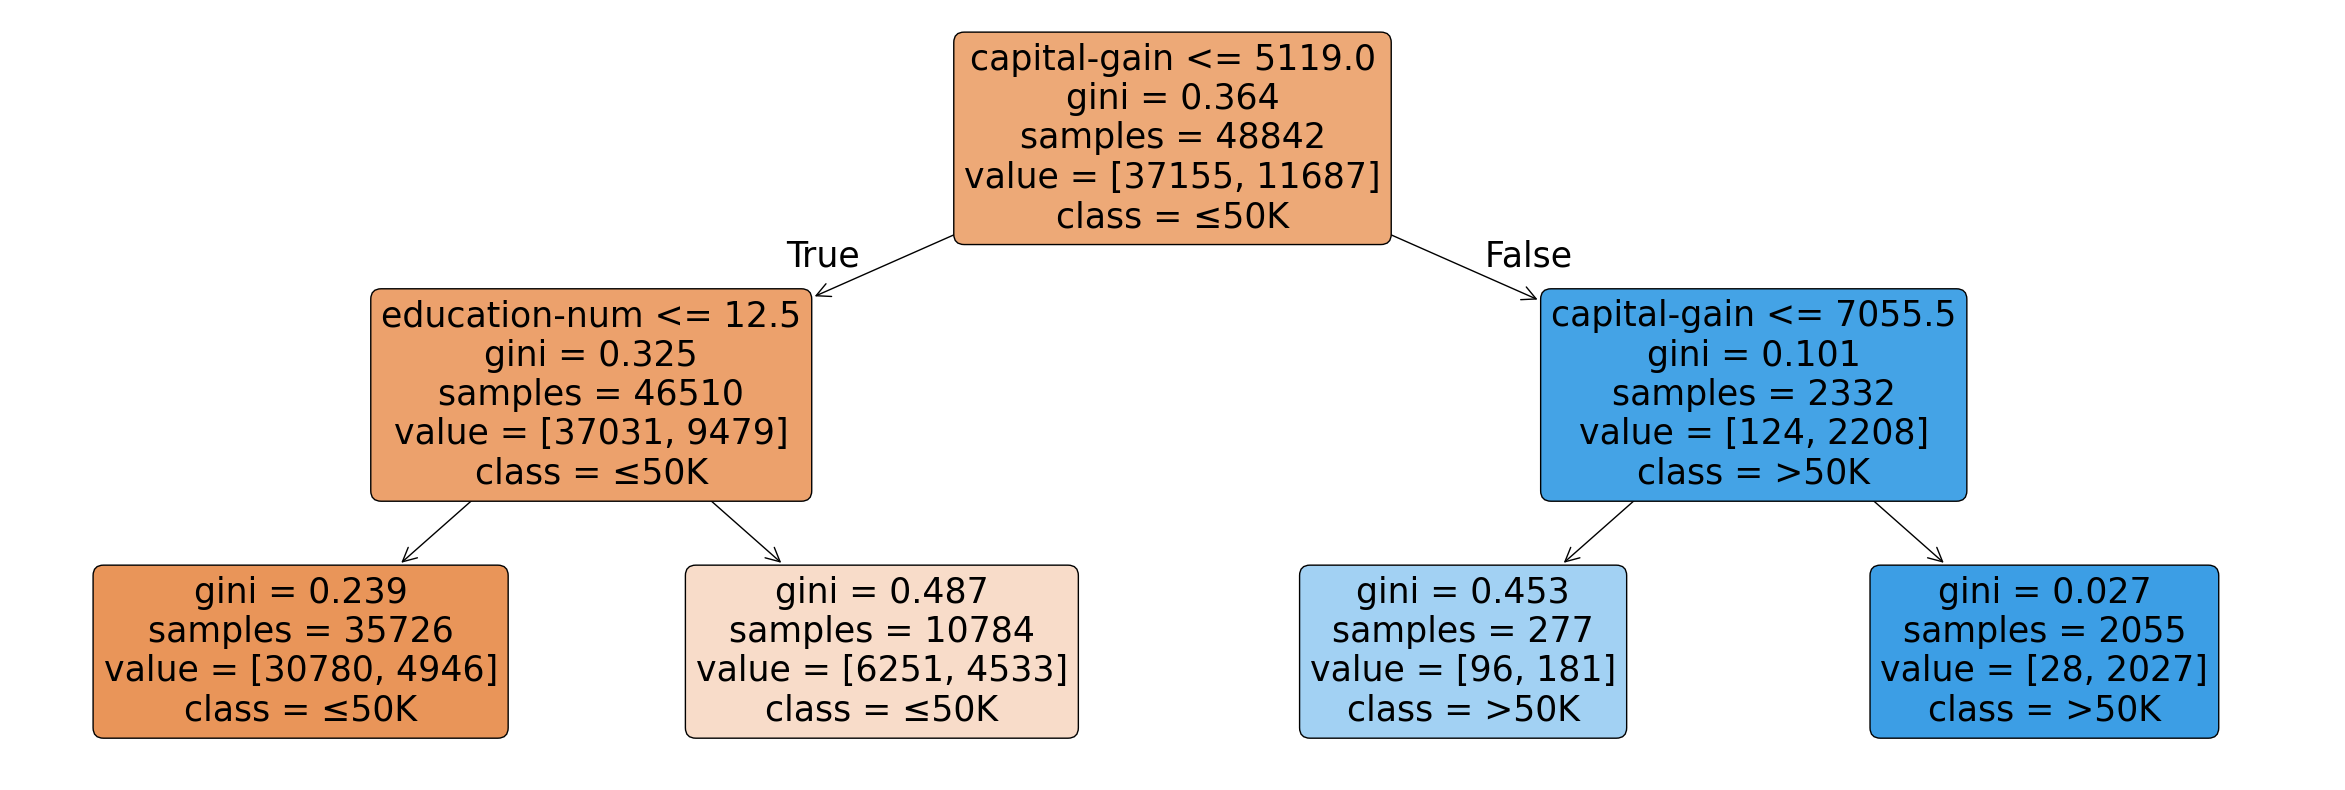

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Entrenamos un árbol simple
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# Visualizamos
plt.figure(figsize=(30, 10))
tree.plot_tree(tree_clf, feature_names=feature_names, class_names=["≤50K", ">50K"],
               filled=True, fontsize=25, rounded=True)
plt.show()


##### **Leyendo el árbol**

De arriba hacia abajo:

1. **Primera pregunta:** *¿Ganancias de capital ≤ $5,119?* — Separa a las pocas personas con altas ganancias de capital (que casi siempre ganan >50K) del resto.
2. **Segunda pregunta (rama izquierda):** *¿Años de educación ≤ 12.5?* — Entre quienes no tienen grandes ganancias de capital, la educación es lo que más importa.

El modelo descubrió que **ganancias de capital** y **educación** son las variables más relevantes — tiene sentido económico (teoría del capital humano).

> **El "Gini" que aparece en cada nodo** mide qué tan mezcladas están las clases: **0 = puro** (todos de la misma clase), **0.5 = máxima mezcla**. El árbol elige en cada paso la pregunta que más reduce el Gini.

##### **¿Cómo construye estas preguntas?**

El algoritmo **CART** prueba cada variable con cada posible umbral (*education-num ≤ 10, 11, 12...*), calcula cuánto reduce el Gini, y elige la mejor opción. Repite en cada sub-grupo. Es **greedy** (voraz): elige lo mejor en cada paso sin garantizar el óptimo global.

#### **2.3 ¿Y si dejamos crecer el árbol sin límites?**

Sin restricciones, un árbol puede hacer una pregunta por cada persona, logrando accuracy perfecto en entrenamiento. Pero con datos nuevos, falla. Esto es **overfitting**.

Piensen en un estudiante: **underfitting** = solo leyó los títulos. **Overfitting** = memorizó el solucionario. El **buen ajuste** está en el medio.

<div align="center">

![Overfitting vs Underfitting](https://scikit-learn.org/stable/_images/sphx_glr_plot_underfitting_overfitting_001.png)

*Izquierda: underfitting. Centro: buen ajuste. Derecha: overfitting. Fuente: [scikit-learn](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html)*

</div>

**¿Cómo se detecta?** Comparando accuracy en **train** vs **test**:

| | **Train** | **Test** | **Diagnóstico** |
|---|---|---|---|
| **Overfitting** | Alta (ej. 99%) | Baja (ej. 75%) | Memorizó — la brecha es la señal |
| **Underfitting** | Baja | Baja | Muy simple para los datos |
| **Buen ajuste** | Alta | Alta (similar) | Generalizó bien |

Veámoslo con nuestros datos:


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Separamos 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Árbol SIN restricciones
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

acc_train = accuracy_score(y_train, tree_clf.predict(X_train))
acc_test = accuracy_score(y_test, tree_clf.predict(X_test))

print(f"Profundidad del árbol: {tree_clf.get_depth()}  |  Hojas: {tree_clf.get_n_leaves()}")
print(f"Accuracy TRAIN: {acc_train:.4f}")
print(f"Accuracy TEST:  {acc_test:.4f}")
print(f"Brecha:         {acc_train - acc_test:.4f}")
print()
if acc_train - acc_test > 0.05:
    print(" Brecha grande: hay OVERFITTING.")


Profundidad del árbol: 33  |  Hojas: 4276
Accuracy TRAIN: 0.8817
Accuracy TEST:  0.8285
Brecha:         0.0532

 Brecha grande: hay OVERFITTING.


##### **La solución: regularizar**

Restringimos el crecimiento del árbol para que **generalice** en vez de memorizar:

| **Parámetro** | **Intuición** |
|---|---|
| `max_depth` | "No hagas más de N preguntas" |
| `min_samples_leaf` | "No crees grupos de menos de N personas" |

Probemos ambos y comparemos:


In [ ]:
# Modelos regularizados
tree_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_depth.fit(X_train, y_train)

tree_leaf = DecisionTreeClassifier(min_samples_leaf=50, random_state=42)
tree_leaf.fit(X_train, y_train)

# Comparación side-by-side
print("=== Comparación Train vs Test ===")
print()
for nombre, modelo in [("Sin regularizar", tree_clf), ("max_depth=3", tree_depth), ("min_samples_leaf=50", tree_leaf)]:
    acc_tr = accuracy_score(y_train, modelo.predict(X_train))
    acc_te = accuracy_score(y_test, modelo.predict(X_test))
    print(f"  {nombre:25s}  Train: {acc_tr:.4f}  |  Test: {acc_te:.4f}  |  Brecha: {acc_tr - acc_te:.4f}")

print("\n La regularización REDUCE la brecha → menos overfitting.")


=== Comparación Train vs Test ===

  Sin regularizar            Train: 0.8817  |  Test: 0.8285  |  Brecha: 0.0532
  max_depth=3                Train: 0.8057  |  Test: 0.8075  |  Brecha: -0.0017
  min_samples_leaf=50        Train: 0.8379  |  Test: 0.8381  |  Brecha: -0.0001

 La regularización REDUCE la brecha → menos overfitting.


#### **2.4 ¿Cómo elegir los mejores hiperparámetros?**

Usamos `max_depth=3` y `min_samples_leaf=50`, pero **¿por qué esos valores y no otros?** Si probamos a mano, podríamos tener suerte con un split particular. **Cross Validation (K-Fold)** resuelve esto:

1. Dividimos el set de entrenamiento en **5 partes**.
2. En cada iteración, una parte distinta es validación y las otras 4 entrenamiento.
3. Promediamos los 5 resultados → estimación estable.

<div align="center">

![K-Fold Cross Validation](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

*Cada iteración usa un fold distinto (rojo) como validación. Fuente: [scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html)*

</div>

Probemos muchos valores de cada parámetro y veamos cuál funciona mejor:


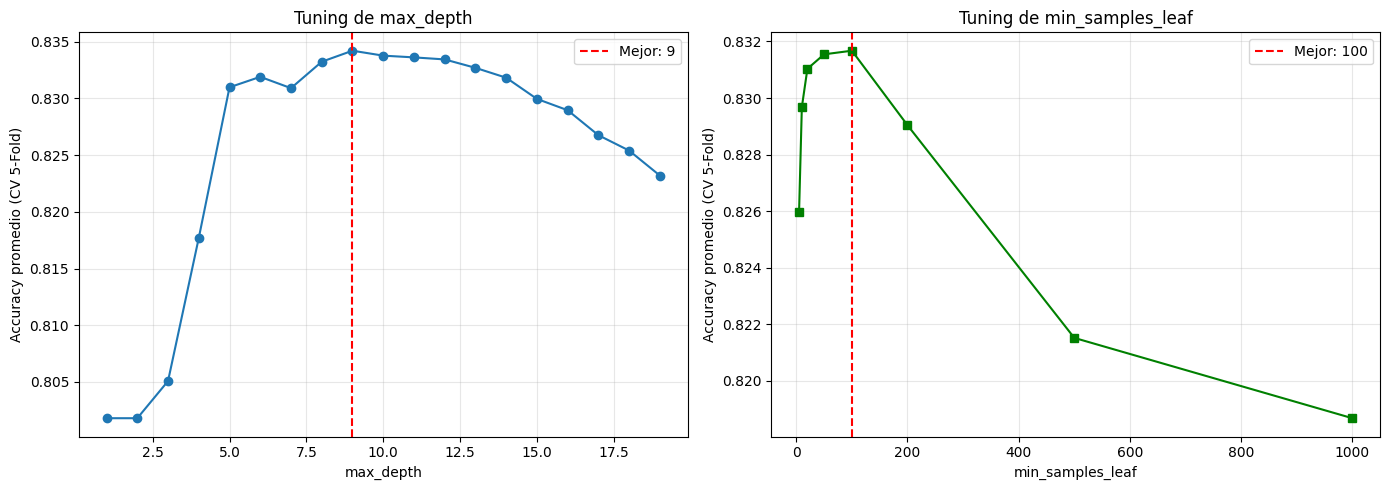

Mejor max_depth: 9 (accuracy CV: 0.8342)
Mejor min_samples_leaf: 100 (accuracy CV: 0.8317)


In [ ]:
from sklearn.model_selection import cross_val_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tuning max_depth
depths = range(1, 20)
cv_depth = [cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
            X_train, y_train, cv=5, scoring="accuracy").mean() for d in depths]

axes[0].plot(list(depths), cv_depth, marker="o")
best_d = list(depths)[np.argmax(cv_depth)]
axes[0].axvline(x=best_d, color="red", linestyle="--", label=f"Mejor: {best_d}")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Accuracy promedio (CV 5-Fold)")
axes[0].set_title("Tuning de max_depth")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Tuning min_samples_leaf
leaves = [5, 10, 20, 50, 100, 200, 500, 1000]
cv_leaf = [cross_val_score(DecisionTreeClassifier(min_samples_leaf=l, random_state=42),
           X_train, y_train, cv=5, scoring="accuracy").mean() for l in leaves]

axes[1].plot(leaves, cv_leaf, marker="s", color="green")
best_l = leaves[np.argmax(cv_leaf)]
axes[1].axvline(x=best_l, color="red", linestyle="--", label=f"Mejor: {best_l}")
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("Accuracy promedio (CV 5-Fold)")
axes[1].set_title("Tuning de min_samples_leaf")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mejor max_depth: {best_d} (accuracy CV: {max(cv_depth):.4f})")
print(f"Mejor min_samples_leaf: {best_l} (accuracy CV: {max(cv_leaf):.4f})")


##### **El flujo completo para combatir el overfitting**

1. Entrenar un modelo **sin restricciones**
2. Comparar accuracy en **train vs test** → si hay brecha grande, hay overfitting
3. Aplicar **regularización** (`max_depth`, `min_samples_leaf`) para simplificar el modelo
4. Usar **Cross Validation** para evaluar distintas configuraciones sin tocar el test set
5. Elegir el modelo con **mejor accuracy promedio en CV**
6. Evaluar **una sola vez** en el test set → resultado final

> **Clave:** el test set se usa **una sola vez al final**. Si lo usamos para ir ajustando hiperparámetros, terminamos haciendo overfitting al test set también. Cross Validation nos da una estimación honesta *sin tocar* el test set.
